<a href="https://colab.research.google.com/github/louis23/spotify-top-hits/blob/louiswang/3_Louis_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir_path='/content/drive/My Drive/Data/Spotify/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mlflow==2.5.0

!databricks configure --host https://community.cloud.databricks.com/


Traceback (most recent call last):
  File "/usr/lib/python3.10/asyncio/base_events.py", line 34, in <module>
    import ssl
  File "/usr/lib/python3.10/ssl.py", line 138, in <module>
    _IntEnum._convert_(
  File "/usr/lib/python3.10/enum.py", line 563, in _convert_
    cls = cls(name, members, module=module)
  File "/usr/lib/python3.10/enum.py", line 387, in __call__
    return cls._create_(
  File "/usr/lib/python3.10/enum.py", line 518, in _create_
    enum_class = metacls.__new__(metacls, class_name, bases, classdict)
  File "/usr/lib/python3.10/enum.py", line 327, in __new__
    if name in classdict:
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 5, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/main.py", line 10, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/u

In [ ]:
import mlflow
mlflow.set_tracking_uri("databricks")
mlflow.set_experiment("/Users/loiuswang88@gmail.com/Models_Louis")


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/2705336010197659', creation_time=1692605475088, experiment_id='2705336010197659', last_update_time=1692935838535, lifecycle_stage='active', name='/Users/loiuswang88@gmail.com/Models_Louis', tags={'mlflow.experiment.sourceName': '/Users/loiuswang88@gmail.com/Models_Louis',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'loiuswang88@gmail.com',
 'mlflow.ownerId': '4845539840753118'}>

In [ ]:
 import pandas as pd

# Read the CSV file into a DataFrame
songs = pd.read_csv("/content/drive/MyDrive/Data/Spotify/data_prepped.csv")
songs.info()
songs['hit'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5954 entries, 0 to 5953
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              5954 non-null   int64  
 1   track_name        5954 non-null   object 
 2   artist_name       5954 non-null   object 
 3   track_id          5954 non-null   object 
 4   danceability      5954 non-null   float64
 5   energy            5954 non-null   float64
 6   key               5954 non-null   int64  
 7   loudness          5954 non-null   float64
 8   mode              5954 non-null   int64  
 9   speechiness       5954 non-null   float64
 10  acousticness      5954 non-null   float64
 11  instrumentalness  5954 non-null   float64
 12  liveness          5954 non-null   float64
 13  valence           5954 non-null   float64
 14  tempo             5954 non-null   float64
 15  duration_ms       5954 non-null   int64  
 16  time_signature    5954 non-null   int64  


0    5000
1     954
Name: hit, dtype: int64

# Scaling Features Before RFECV

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Columns to be scaled using MinMaxScaler
minmax_features = ['danceability', 'energy', 'speechiness', 'acousticness',
                   'instrumentalness', 'liveness', 'valence', 'duration_ms'] # 'mode' is not scaled as it is either 0 or 1

# Columns to be scaled using StandardScaler
standard_features = ['loudness', 'tempo']

songs_scaled = songs.copy()
# Apply MinMaxScaler to selected columns
minmax_scaler = MinMaxScaler()
songs_scaled[minmax_features] = minmax_scaler.fit_transform(songs_scaled[minmax_features])


# Apply StandardScaler to selected columns
standard_scaler = StandardScaler()
songs_scaled[standard_features] = standard_scaler.fit_transform(songs_scaled[standard_features])

from sklearn.preprocessing import LabelEncoder

# Encoding 'key' and 'time_signature'
key_encoder = LabelEncoder()
songs_scaled['key_encoded'] = key_encoder.fit_transform(songs_scaled['key'])
time_sig_encoder = LabelEncoder()
songs_scaled['time_signature_encoded'] = time_sig_encoder.fit_transform(songs_scaled['time_signature'])


# Drop the original columns 'key' and 'time_signature' if desired
songs_scaled.drop(['key', 'time_signature'], axis=1, inplace=True)

# Drop columns that are not relevant to the problem
songs_scaled.drop(['year', 'track_name', 'artist_name', 'track_id'], axis=1, inplace=True)

songs_scaled.head()

# Feature Selection
## Correlation Matrix

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt


# Compute the correlation matrix for the selected columns
correlation_matrix = songs_scaled.corr()

plt.figure(figsize=(10, 8))

# Print the correlation matrix
# print(correlation_matrix)
sn.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdYlBu")

# X = songs_scaled[['danceability','energy','key_encoded','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature_encoded']]


# Feature selection using Recursive

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

# Assuming you have your feature matrix X and target vector y
# Initialize the model
model = LogisticRegression()

# Initialize the RFECV with the model and the desired cross-validation strategy
rfecv = RFECV(estimator=model, step=1, cv=5, scoring='accuracy')

X = songs_scaled[['danceability','energy','loudness', 'mode','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms','key_encoded', 'time_signature_encoded']]
y = songs_scaled['hit']
# Fit RFECV on your data
rfecv.fit(X, y)

# Get the optimal number of features and the selected features
optimal_num_features = rfecv.n_features_
selected_features = X.columns[rfecv.support_]

# Print the results
print("Optimal number of features:", optimal_num_features)
print("Selected features:", selected_features)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Optimal number of features: 6
Selected features: Index(['danceability', 'energy', 'loudness', 'acousticness',
       'instrumentalness', 'liveness'],
      dtype='object')


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

# Initialize the RFECV with the model and the desired cross-validation strategy
rfecv = RFECV(estimator=model, step=1, cv=10, scoring='accuracy')

# Fit RFECV on data
rfecv.fit(X, y)

# Get the optimal number of features and the selected features
optimal_num_features = rfecv.n_features_
selected_features = X.columns[rfecv.support_]

# Print the results
print("Optimal number of features:", optimal_num_features)
print("Selected features:", selected_features)




Optimal number of features: 7
Selected features: Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'valence'],
      dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

# Initialize the RFECV with the model and the desired cross-validation strategy
rfecv = RFECV(estimator=model, step=1, cv=20, scoring='accuracy')

# Fit RFECV on your data
rfecv.fit(X, y)

# Get the optimal number of features and the selected features
optimal_num_features = rfecv.n_features_
selected_features = X.columns[rfecv.support_]

# Print the results
print("Optimal number of features:", optimal_num_features)
print("Selected features:", selected_features)


Optimal number of features: 10
Selected features: Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='object')


In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Initialize the RFECV with the model and the desired cross-validation strategy
rfecv = RFECV(estimator=model, step=1, cv=5, scoring='f1')

X = songs_scaled[['danceability','energy','loudness', 'mode','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms','key_encoded', 'time_signature_encoded']]
y = songs_scaled['hit']

# Fit RFECV on data
rfecv.fit(X, y)

# Get the optimal number of features and the selected features
optimal_num_features = rfecv.n_features_
selected_features = X.columns[rfecv.support_]

# Print the results
print("Optimal number of features:", optimal_num_features)
print("Selected features:", selected_features)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Optimal number of features: 12
Selected features: Index(['danceability', 'energy', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature_encoded'],
      dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

# Initialize the RFECV with the model and the desired cross-validation strategy
rfecv = RFECV(estimator=model, step=1, cv=10, scoring='f1')

# Fit RFECV on data
rfecv.fit(X, y)

# Get the optimal number of features and the selected features
optimal_num_features = rfecv.n_features_
selected_features = X.columns[rfecv.support_]

# Print the results
print("Optimal number of features:", optimal_num_features)
print("Selected features:", selected_features)




Optimal number of features: 7
Selected features: Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'valence'],
      dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

# Initialize the RFECV with the model and the desired cross-validation strategy
rfecv = RFECV(estimator=model, step=1, cv=20, scoring='f1')

# Fit RFECV on data
rfecv.fit(X, y)

# Get the optimal number of features and the selected features
optimal_num_features = rfecv.n_features_
selected_features = X.columns[rfecv.support_]

# Print the results
print("Optimal number of features:", optimal_num_features)
print("Selected features:", selected_features)


Optimal number of features: 10
Selected features: Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='object')


Based on the above RFECV models, we can drop 'key' and 'time_signature'

In [ ]:
X = songs_scaled[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms',]]
y = songs_scaled['hit']

In [ ]:
mlflow.end_run()
mlflow.sklearn.autolog(disable=True)
mlflow.sklearn.autolog()

# Metric used: F1 score (for minority class)

Since hits are the minority class, we value the correct prediction of hits by the model

# Logistic Regression: Balancing dataset using class-weights

In [ ]:
# Logistic regression
# Using selected features from RFECV
# Data not balanced yet

current_run = mlflow.start_run()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,roc_curve, roc_auc_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report


X = songs_scaled[['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'liveness']]
y = songs_scaled['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Create a logistic regression object
logreg = LogisticRegression()

# Train the model on the training data
logreg.fit(X_train, y_train)

# Make predictions on the test data
y_pred = logreg.predict(X_test)

print(f'Accuracy Score: {accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print(classification_report(y_test,y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


2023/08/25 04:10:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.10/dist-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils."


Accuracy Score: 0.8530646515533166
Confusion Matrix: 
[[984  28]
 [147  32]]
Area Under Curve: 0.5755514827654736
Recall score: 0.1787709497206704
Precision: 0.5333333333333333
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1012
           1       0.53      0.18      0.27       179

    accuracy                           0.85      1191
   macro avg       0.70      0.58      0.59      1191
weighted avg       0.82      0.85      0.82      1191

F1 score for minority class: 0.26778242677824265


In [ ]:
# Logistic regression
# Using all features except key and timesig
# Data not balanced yet

current_run = mlflow.start_run()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,roc_curve, roc_auc_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import f1_score

X = songs_scaled[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms',]]
y = songs_scaled['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Create a logistic regression object
logreg = LogisticRegression()

# Train the model on the training data
logreg.fit(X_train, y_train)

# Make predictions on the test data
y_pred = logreg.predict(X_test)

print(f'Accuracy Score: {accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print(classification_report(y_test,y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


Accuracy Score: 0.8497061293031066
Confusion Matrix: 
[[982  30]
 [149  30]]
Area Under Curve: 0.5689767482942124
Recall score: 0.16759776536312848
Precision: 0.5
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1012
           1       0.50      0.17      0.25       179

    accuracy                           0.85      1191
   macro avg       0.68      0.57      0.58      1191
weighted avg       0.81      0.85      0.82      1191

F1 score for minority class: 0.2510460251046025


In [ ]:
class_ratio = 5000 / 954
class_weight = {0: 1, 1: class_ratio}


In [ ]:
# define weight hyperparameter
w = [{0:1000,1:100},{0:1000,1:10}, {0:1000,1:1.0},
     {0:500,1:1.0}, {0:400,1:1.0}, {0:300,1:1.0}, {0:200,1:1.0},
     {0:150,1:1.0}, {0:100,1:1.0}, {0:99,1:1.0}, {0:10,1:1.0},
     {0:0.01,1:1.0}, {0:0.01,1:10}, {0:0.01,1:100},
     {0:0.001,1:1.0}, {0:0.005,1:1.0}, {0:1.0,1:1.0},
     {0:1.0,1:0.1}, {0:10,1:0.1}, {0:100,1:0.1},
     {0:10,1:0.01}, {0:1.0,1:0.01}, {0:1.0,1:0.001}, {0:1.0,1:0.005},
     {0:1.0,1:10}, {0:1.0,1:99}, {0:1.0,1:100}, {0:1.0,1:150},
     {0:1.0,1:200}, {0:1.0,1:300},{0:1.0,1:400},{0:1.0,1:500},
     {0:1.0,1:1000}, {0:10,1:1000},{0:100,1:1000}, {0: 954, 1: 5000}, {0: 1000, 1: 6000} ]
hyperparam_grid = {"class_weight": w }

In [ ]:
# define model
lg3 = LogisticRegression(random_state=39)
from sklearn.model_selection import GridSearchCV

# define evaluation procedure
grid = GridSearchCV(lg3,hyperparam_grid,scoring="f1", cv=100, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)
print(f'Best score: {grid.best_score_} with param: {grid.best_params_}')

2023/08/25 04:10:21 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '38b40666a07a4601806e64ef345b0084', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/08/25 04:10:21 WARNING mlflow.utils: Truncated the value of the key `param_grid`. Truncated value: `{'class_weight': [{0: 1000, 1: 100}, {0: 1000, 1: 10}, {0: 1000, 1: 1.0}, {0: 500, 1: 1.0}, {0: 400, 1: 1.0}, {0: 300, 1: 1.0}, {0: 200, 1: 1.0}, {0: 150, 1: 1.0}, {0: 100, 1: 1.0}, {0: 99, 1: 1.0}, {0: 10, 1: 1.0}, {0: 0.01, 1: 1.0}, {0: 0.01, 1: 10}, {0: 0.01, 1: 100}, {0: 0.001, 1: 1.0}, {0: 0.005, 1: 1.0}, {0: 1.0, 1: 1.0}, {0: 1.0, 1: 0.1}, {0: 10, 1: 0.1}, {0: 100, 1: 0.1}, {0: 10, 1: 0.01}, {0: 1.0, 1: 0.01}, {0: 1.0, 1: 0.001}, {0: 1.0, 1: 0.005}, {0: 1.0, 1: 10}, {0: 1.0, 1: 99}, {0:...`
2023/08/25 04:12:15 INFO mlflow.sklearn.utils: Logging the 5 best runs, 32 runs will be omitted.


Best score: 0.5132656096650419 with param: {'class_weight': {0: 954, 1: 5000}}


In [ ]:
from sklearn.metrics import classification_report

current_run = mlflow.start_run()

# define model
lg3 = LogisticRegression(random_state=13, class_weight='balanced')
# fit it
lg3.fit(X_train,y_train)
# test
y_pred = lg3.predict(X_test)
# performance
print(f'Accuracy Score: {accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print(classification_report(y_test,y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()

Accuracy Score: 0.746431570109152
Confusion Matrix: 
[[736 276]
 [ 26 153]]
Area Under Curve: 0.7910106653123413
Recall score: 0.8547486033519553
Precision: 0.35664335664335667
              precision    recall  f1-score   support

           0       0.97      0.73      0.83      1012
           1       0.36      0.85      0.50       179

    accuracy                           0.75      1191
   macro avg       0.66      0.79      0.67      1191
weighted avg       0.87      0.75      0.78      1191

F1 score for minority class: 0.5032894736842105


In [ ]:
# Logistic regression
# Using all features except key and timesig
# Data balanced
import numpy as np
from sklearn.metrics import classification_report



current_run = mlflow.start_run()

X = songs_scaled[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms',]]
y = songs_scaled['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Define a list of threshold values to test
thresholds = np.arange(0.1, 1.0, 0.1)

# Initialize an empty dictionary to store results for each threshold
classification_reports = {}

# Iterate over threshold values and evaluate logistic regression models
for threshold in thresholds:
    # Train a new logistic regression model for each threshold with specific class weights
    logreg = LogisticRegression(random_state=39, class_weight={0: 954, 1: 5000})

    # Fit the model
    logreg.fit(X_train, y_train)

    # Predict probabilities
    y_prob = logreg.predict_proba(X_test)[:, 1]

    # Apply the threshold to make binary predictions
    y_pred = np.where(y_prob >= threshold, 1, 0)

    # Calculate and store the classification report
    report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'], output_dict=True)
    classification_reports[threshold] = report

    # Calculate test metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    # Calculate recall score for the minority class (assuming minority class label is 1)
    f1_1 = f1_score(y_test, y_pred, labels=[1])

    # Print the recall score for the minority class
    print(f'F1 score for minority class: {f1_1}')
    # Log test metrics manually
    mlflow.log_metrics({
            "test_accuracy": test_accuracy,
            "test_roc_auc": roc_auc,
            "test_recall": recall,
            "test_precision": precision,
            "test_f1": f1,
            "test_f1_1": f1_1
    })
# Print or access the classification reports for each threshold
for threshold, report in classification_reports.items():
    print(f"Threshold {threshold}:")
    print(classification_report(y_test, np.where(y_prob >= threshold, 1, 0), target_names=['Class 0', 'Class 1']))



mlflow.end_run()

F1 score for minority class: 0.3612512613521695
F1 score for minority class: 0.39207048458149774
F1 score for minority class: 0.42735042735042733
F1 score for minority class: 0.46153846153846156
F1 score for minority class: 0.5106382978723404
F1 score for minority class: 0.5069306930693069
F1 score for minority class: 0.4927536231884058
F1 score for minority class: 0.4158415841584158
F1 score for minority class: 0.18433179723502302
Threshold 0.1:
              precision    recall  f1-score   support

     Class 0       1.00      0.37      0.54      1012
     Class 1       0.22      1.00      0.36       179

    accuracy                           0.47      1191
   macro avg       0.61      0.69      0.45      1191
weighted avg       0.88      0.47      0.52      1191

Threshold 0.2:
              precision    recall  f1-score   support

     Class 0       1.00      0.46      0.63      1012
     Class 1       0.24      0.99      0.39       179

    accuracy                           0.54

| Threshold | Accuracy | Precision | Recall | F1 Score |
|-----------|----------|-----------|--------|----------|
| 0.1       | 0.47     | 0.22      | 1.00   | 0.36     |
| 0.2       | 0.54     | 0.24      | 0.99   | 0.39     |
| 0.3       | 0.61     | 0.27      | 0.98   | 0.43     |
| 0.4       | 0.67     | 0.31      | 0.94   | 0.46     |
| 0.5       | 0.75     | 0.36      | 0.87   | 0.51     |
| 0.6       | 0.79     | 0.39      | 0.72   | 0.51     |
| 0.7       | 0.82     | 0.43      | 0.57   | 0.49     |
| 0.8       | 0.85     | 0.51      | 0.35   | 0.42     |
| 0.9       | 0.85     | 0.53      | 0.11   | 0.18     |


In [ ]:
# Logistic regression
# Using 6 features recommended by RFECV
# Data not balanced
from sklearn.metrics import classification_report

current_run = mlflow.start_run()

X = songs_scaled[['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'liveness']]
y = songs_scaled['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# define model
lg3 = LogisticRegression(random_state=13, class_weight={0: 954, 1: 5000})
# fit it
lg3.fit(X_train,y_train)
# test
y_pred = lg3.predict(X_test)
# performance
print(f'Accuracy Score: {accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print(classification_report(y_test,y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()

Accuracy Score: 0.743073047858942
Confusion Matrix: 
[[735 277]
 [ 29 150]]
Area Under Curve: 0.7821367058979398
Recall score: 0.8379888268156425
Precision: 0.351288056206089
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      1012
           1       0.35      0.84      0.50       179

    accuracy                           0.74      1191
   macro avg       0.66      0.78      0.66      1191
weighted avg       0.87      0.74      0.78      1191

F1 score for minority class: 0.49504950495049505


# K-Nearest Neighbours (using class_weights 954:5000)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

current_run = mlflow.start_run()

X = songs_scaled[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]
y = songs_scaled['hit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

class_weights = {0: 954, 1: 5000}

# Convert y_train to a numpy array
y_train_array = y_train.to_numpy()

# Create a weighted KNeighborsClassifier with inverse class frequency
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')  # Using 'distance' for weighted KNN

# Fit the model on the training data
knn.fit(X_train, y_train_array)

y_pred = knn.predict(X_test)

print(f'Accuracy Score: {accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print(classification_report(y_test,y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()

Accuracy Score: 0.8396305625524769
Confusion Matrix: 
[[938  74]
 [117  62]]
Area Under Curve: 0.636623092719765
Recall score: 0.3463687150837989
Precision: 0.45588235294117646
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1012
           1       0.46      0.35      0.39       179

    accuracy                           0.84      1191
   macro avg       0.67      0.64      0.65      1191
weighted avg       0.82      0.84      0.83      1191

F1 score for minority class: 0.3936507936507937


# One Class Support Vector Machine
## Chosen to replicate unsupervised learning

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

current_run = mlflow.start_run()

X = songs_scaled[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]
y = songs_scaled['hit']

# Train the One-Class SVM model
ocsvm = OneClassSVM(nu=0.05, kernel='rbf')  # You can adjust nu and kernel as needed
ocsvm.fit(X)

# Predict anomalies (outliers)
y_pred = ocsvm.predict(X)
y_pred = [1 if label == -1 else 0 for label in y_pred]  # Convert -1 to 1 and 1 to 0 for comparison

print('Accuracy Score:', accuracy_score(y, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y, y_pred))
print('Classification Report:\n', classification_report(y, y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred)
recall = recall_score(y, y_pred)
precision = precision_score(y, y_pred)
f1 = f1_score(y, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()

#poor results

2023/08/25 04:13:40 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


Accuracy Score: 0.7917366476318441
Confusion Matrix:
 [[4707  293]
 [ 947    7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88      5000
           1       0.02      0.01      0.01       954

    accuracy                           0.79      5954
   macro avg       0.43      0.47      0.45      5954
weighted avg       0.70      0.79      0.74      5954

F1 score for minority class: 0.01116427432216906


# Random Forest with class weights

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score

current_run = mlflow.start_run()

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=39)

X = songs_scaled[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms',]]
y = songs_scaled['hit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)


cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=39)

# Specify the scoring metric
scoring = make_scorer(roc_auc_score)

# Perform cross-validation using RepeatedStratifiedKFold
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring=scoring)


# Print the AUC scores for each fold
for fold, score in enumerate(cv_scores, start=1):
    print(f"Fold {fold}: AUC = {score:.2f}")

# Print the average AUC score across all folds
average_auc = cv_scores.mean()
print(f"Average AUC across folds: {average_auc:.2f}")

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)
print('Random Forest accuracy', accuracy_score(y_test, y_pred))
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print(classification_report(y_test,y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()

Fold 1: AUC = 0.67
Fold 2: AUC = 0.61
Fold 3: AUC = 0.66
Fold 4: AUC = 0.65
Fold 5: AUC = 0.63
Fold 6: AUC = 0.63
Fold 7: AUC = 0.63
Fold 8: AUC = 0.65
Fold 9: AUC = 0.64
Fold 10: AUC = 0.64
Fold 11: AUC = 0.67
Fold 12: AUC = 0.62
Fold 13: AUC = 0.62
Fold 14: AUC = 0.66
Fold 15: AUC = 0.65
Average AUC across folds: 0.64
Cross-validation scores: [0.67465842 0.61023527 0.66184817 0.65026511 0.62965556 0.62689789
 0.63228232 0.64562616 0.6443518  0.64318614 0.670992   0.62251192
 0.61865955 0.65976444 0.65349091]
Mean CV score: 0.6429617110868535
Random Forest accuracy 0.8690176322418136
Confusion Matrix: 
[[973  39]
 [117  62]]
Area Under Curve: 0.6539155828383422
Recall score: 0.3463687150837989
Precision: 0.6138613861386139
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      1012
           1       0.61      0.35      0.44       179

    accuracy                           0.87      1191
   macro avg       0.75      0.65      0.68     

# XGBoost

In [ ]:
import xgboost as xgb

current_run = mlflow.start_run()

# Initialize the XGBoost classifier with class weights
model = xgb.XGBClassifier(scale_pos_weight=5000/954)  # Adjust the ratio as needed

X = songs_scaled[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms',]]
y = songs_scaled['hit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

scoring = make_scorer(roc_auc_score)
# Calculate accuracy
cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring=scoring)

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print('XGBoost accuracy', accuracy_score(y_test, y_pred))
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()

Cross-validation scores: [0.71674378 0.69876615 0.72537112 0.71337434 0.71383003 0.71986785
 0.80428344 0.75358852 0.70226131 0.76359361]
Mean CV accuracy: 0.7311680143007834
XGBoost accuracy 0.8513853904282116
Confusion Matrix: 
[[904 108]
 [ 69 110]]
Area Under Curve: 0.7539028860379358
Recall score: 0.6145251396648045
Precision: 0.5045871559633027
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      1012
           1       0.50      0.61      0.55       179

    accuracy                           0.85      1191
   macro avg       0.72      0.75      0.73      1191
weighted avg       0.87      0.85      0.86      1191

F1 score for minority class: 0.5541561712846348


## XGBoost with RepeatedStratifiedKFold as baseline



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np

X = songs_scaled[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms']]
y = songs_scaled['hit']

current_run = mlflow.start_run()

# Initialize the XGBoost classifier with class weights
# model = xgb.XGBClassifier(scale_pos_weight=5000/954)  # Adjust the ratio as needed
model = XGBClassifier()

# define evaluation procedure
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
# evaluate model
scores = cross_val_score(model, X, y, scoring='f1', cv=cv, n_jobs=-1)
# summarize performance
mean_f1 = np.mean(scores)
print('Mean F1:', mean_f1)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})
print(classification_report(y_test, y_pred))


mlflow.end_run()


Mean F1: 0.49214468106553727
F1 score for minority class: 0.5541561712846348
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      1012
           1       0.50      0.61      0.55       179

    accuracy                           0.85      1191
   macro avg       0.72      0.75      0.73      1191
weighted avg       0.87      0.85      0.86      1191



## XGBoost with RepeatedStratifiedKFold and class weights to balance dataset

In [ ]:
from xgboost import XGBClassifier
import numpy as np

X = songs_scaled[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms']]
y = songs_scaled['hit']

current_run = mlflow.start_run()

# Initialize the XGBoost classifier with class weights
# model = xgb.XGBClassifier(scale_pos_weight=5000/954)  # Adjust the ratio as needed
model = XGBClassifier(scale_pos_weight=5000/954)

# define evaluation procedure
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
# evaluate model
scores = cross_val_score(model, X, y, scoring='f1', cv=cv, n_jobs=-1)
# summarize performance
mean_f1 = np.mean(scores)
print('Mean F1:', mean_f1)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})
print(classification_report(y_test, y_pred))


mlflow.end_run()


Mean F1: 0.5513678964693994
F1 score for minority class: 0.5541561712846348
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      1012
           1       0.50      0.61      0.55       179

    accuracy                           0.85      1191
   macro avg       0.72      0.75      0.73      1191
weighted avg       0.87      0.85      0.86      1191



## Tune the Class Weighting Hyperparameter


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

X = songs_scaled[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms']]
y = songs_scaled['hit']

current_run = mlflow.start_run()

model = XGBClassifier()

# define grid
weights = [1, 10, 25, 50, 75, 99, 100, 1000]
param_grid = dict(scale_pos_weight=weights)

# define evaluation procedure
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# define grid search
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=cv, scoring='f1')
# execute the grid search
grid_result = grid.fit(X, y)
# report the best configuration
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
# report all configurations
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

print(classification_report(y_test, y_pred))

mlflow.end_run()


Best: 0.559748 using {'scale_pos_weight': 75}
0.492145 (0.045450) with: {'scale_pos_weight': 1}
0.556941 (0.032378) with: {'scale_pos_weight': 10}
0.559183 (0.034787) with: {'scale_pos_weight': 25}
0.553454 (0.032215) with: {'scale_pos_weight': 50}
0.559748 (0.034586) with: {'scale_pos_weight': 75}
0.553687 (0.027473) with: {'scale_pos_weight': 99}
0.554265 (0.031102) with: {'scale_pos_weight': 100}
0.551258 (0.024411) with: {'scale_pos_weight': 1000}
F1 score for minority class: 0.5541561712846348
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      1012
           1       0.50      0.61      0.55       179

    accuracy                           0.85      1191
   macro avg       0.72      0.75      0.73      1191
weighted avg       0.87      0.85      0.86      1191



## XGBoost with class weights set as 75

In [ ]:
current_run = mlflow.start_run()

import xgboost as xgb

X = songs_scaled[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms']]
y = songs_scaled['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Initialize the XGBoost classifier with class weights
model = xgb.XGBClassifier(scale_pos_weight=75)  # Adjust the ratio as needed

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

scoring = make_scorer(roc_auc_score)
# Calculate accuracy
cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring=scoring)

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print('XGBoost accuracy', accuracy_score(y_test, y_pred))
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()

# winner

Cross-validation scores: [0.71857528 0.73028726 0.74156545 0.74196856 0.75791752 0.7400319
 0.80268854 0.7911825  0.75028991 0.76034016]
Mean CV accuracy: 0.753484708450326
XGBoost accuracy 0.8203190596137699
Confusion Matrix: 
[[843 169]
 [ 45 134]]
Area Under Curve: 0.7908036522622386
Recall score: 0.7486033519553073
Precision: 0.44224422442244227
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1012
           1       0.44      0.75      0.56       179

    accuracy                           0.82      1191
   macro avg       0.70      0.79      0.72      1191
weighted avg       0.87      0.82      0.84      1191

F1 score for minority class: 0.5560165975103735


## XBGoost with Optuna

In [ ]:
!pip install optuna
import optuna
current_run = mlflow.start_run()

X = songs_scaled[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms']]
y = songs_scaled['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameters to search
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'booster': trial.suggest_categorical('booster', ['gbtree', 'gblinear', 'dart']),
        'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'eta': trial.suggest_loguniform('eta', 0.001, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 10.0),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
    }

    # Create the XGBoost model with the suggested hyperparameters
    model = xgb.XGBClassifier(**params)

    # Train the model on the training data
    model.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred = model.predict(X_test)

    # Calculate the F1 score to optimize
    f1 = f1_score(y_test, y_pred)

    return f1

# Create an Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Get the best hyperparameters
best_params = study.best_params
best_score = study.best_value

print(f"Best Hyperparameters: {best_params}")
print(f"Best F1 Score: {best_score:.4f}")

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.2/404.2 kB 12.3 MB/s eta 0:00:00


[I 2023-08-25 04:22:50,925] A new study created in memory with name: no-name-16b83ed0-af55-4b57-a5b4-c727800b84e2


  0%|          | 0/100 [00:00<?, ?it/s]

<ipython-input-62-1d30509226ab>:17: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
<ipython-input-62-1d30509226ab>:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
<ipython-input-62-1d30509226ab>:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'eta': trial.suggest_loguniform('eta', 0.001, 1.0),
<ipython-input-62-1d30509226ab>:17: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This f

[04:22:50] WARNING: ../src/learner.cc:767: 
Parameters: { "colsample_bytree", "max_depth", "min_child_weight", "subsample" } are not used.

[I 2023-08-25 04:22:51,053] Trial 0 finished with value: 0.0 and parameters: {'booster': 'gblinear', 'lambda': 0.5606690929299261, 'alpha': 0.00011123356501553437, 'max_depth': 3, 'eta': 0.0016019647666011723, 'min_child_weight': 9.933712666255621, 'subsample': 0.5705421538424086, 'colsample_bytree': 0.3381314286845489}. Best is trial 0 with value: 0.0.
[I 2023-08-25 04:22:51,714] Trial 1 finished with value: 0.05291005291005291 and parameters: {'booster': 'gbtree', 'lambda': 0.0002661242000410756, 'alpha': 3.1434011139630174e-08, 'max_depth': 7, 'eta': 0.001408584920690309, 'min_child_weight': 6.208408839535042, 'subsample': 0.6630960690752707, 'colsample_bytree': 0.5485792378681921}. Best is trial 1 with value: 0.05291005291005291.


...

[I 2023-08-25 04:24:27,773] Trial 96 finished with value: 0.4873417721518988 and parameters: {'booster': 'gbtree', 'lambda': 0.007276142267677218, 'alpha': 0.01200114633250511, 'max_depth': 3, 'eta': 0.20413611613563673, 'min_child_weight': 7.1714465902290225, 'subsample': 0.8091309104666408, 'colsample_bytree': 0.5156710406658325}. Best is trial 27 with value: 0.5344827586206896.


<ipython-input-62-1d30509226ab>:17: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
<ipython-input-62-1d30509226ab>:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
<ipython-input-62-1d30509226ab>:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'eta': trial.suggest_loguniform('eta', 0.001, 1.0),
<ipython-input-62-1d30509226ab>:17: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This f

[I 2023-08-25 04:24:28,136] Trial 97 finished with value: 0.45747800586510257 and parameters: {'booster': 'gbtree', 'lambda': 0.00394726008650988, 'alpha': 0.00714243657916912, 'max_depth': 4, 'eta': 0.46373021429435174, 'min_child_weight': 8.031947265912729, 'subsample': 0.656108372383141, 'colsample_bytree': 0.45849665959812286}. Best is trial 27 with value: 0.5344827586206896.
[04:24:28] WARNING: ../src/learner.cc:767: 
Parameters: { "colsample_bytree", "max_depth", "min_child_weight", "subsample" } are not used.

[I 2023-08-25 04:24:28,282] Trial 98 finished with value: 0.0 and parameters: {'booster': 'gblinear', 'lambda': 0.051698115841342096, 'alpha': 0.0044150806038084885, 'max_depth': 9, 'eta': 0.2770625845076928, 'min_child_weight': 7.451382651025568, 'subsample': 0.7114214915074283, 'colsample_bytree': 0.5482023022558499}. Best is trial 27 with value: 0.5344827586206896.


<ipython-input-62-1d30509226ab>:17: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
<ipython-input-62-1d30509226ab>:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
<ipython-input-62-1d30509226ab>:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'eta': trial.suggest_loguniform('eta', 0.001, 1.0),


[I 2023-08-25 04:24:28,838] Trial 99 finished with value: 0.46302250803858525 and parameters: {'booster': 'gbtree', 'lambda': 0.0022755198307016903, 'alpha': 0.0002020388530435545, 'max_depth': 5, 'eta': 0.1390594245579198, 'min_child_weight': 8.231961435955462, 'subsample': 0.755143183144427, 'colsample_bytree': 0.6547214962214604}. Best is trial 27 with value: 0.5344827586206896.
Best Hyperparameters: {'booster': 'dart', 'lambda': 0.016809615947769457, 'alpha': 0.0003605828948081159, 'max_depth': 5, 'eta': 0.32008274867239933, 'min_child_weight': 6.890881097638313, 'subsample': 0.5764605637582427, 'colsample_bytree': 0.5600401751300451}
Best F1 Score: 0.5345
F1 score for minority class: 0.5560165975103735


In [ ]:
mlflow.end_run()


# Feature Importance for XGB

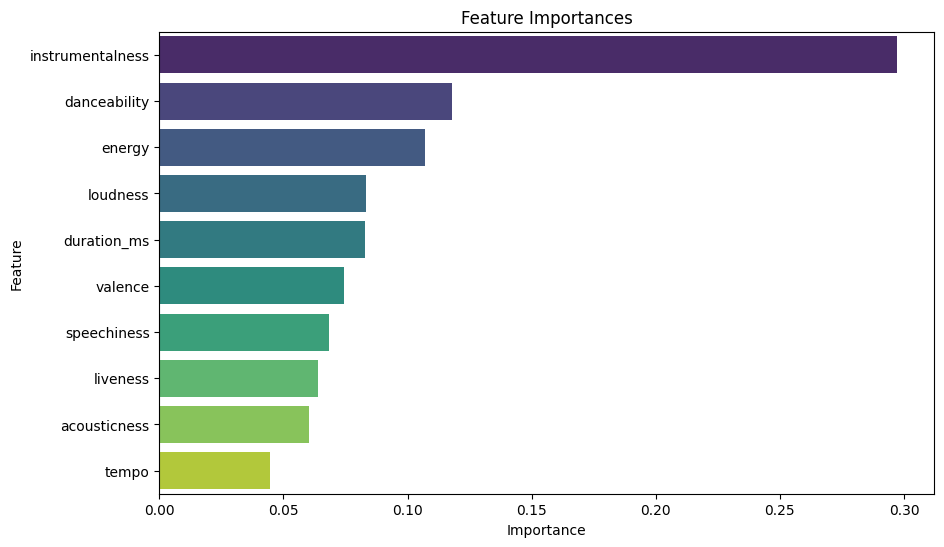

In [ ]:
import seaborn as sns

# Feature importance calculation
feature_importance = model.feature_importances_

# Create a DataFrame for easier plotting
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the horizontal bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


# AdaBoost


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

current_run = mlflow.start_run()

ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, max_features=4, random_state=39))

param_grid = {'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400],
              'learning_rate': [0.3, 0.1, 0.01]}

scoring = make_scorer(roc_auc_score)

gr_ada_clf = GridSearchCV(ada_clf,
                          param_grid=param_grid,
                          scoring=scoring,
                          n_jobs=-1)

gr_ada_clf = gr_ada_clf.fit(X_train, y_train)

print(gr_ada_clf.best_params_)

print('AdaBoost accuracy', accuracy_score(y_test, y_pred))
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()



{'learning_rate': 0.3, 'n_estimators': 400}
AdaBoost accuracy 0.8203190596137699
Area Under Curve: 0.7908036522622386
Recall score: 0.7486033519553073
Precision: 0.44224422442244227
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1012
           1       0.44      0.75      0.56       179

    accuracy                           0.82      1191
   macro avg       0.70      0.79      0.72      1191
weighted avg       0.87      0.82      0.84      1191

F1 score for minority class: 0.5560165975103735


# Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

current_run = mlflow.start_run()

X = songs[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms']]
y = songs['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

param_grid = {'n_estimators': [50, 100, 200, 300, 400], 'learning_rate': [0.1, 0.01]}

gr_gb_clf = GridSearchCV(GradientBoostingClassifier(max_features=4, random_state=39),
                      param_grid=param_grid,
                      scoring='accuracy',
                      n_jobs=-1)

gr_gb_clf = gr_gb_clf.fit(X_train, y_train)

print('GradientBoost accuracy', accuracy_score(y_test, y_pred))
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


GradientBoost accuracy 0.8203190596137699
Area Under Curve: 0.7908036522622386
Recall score: 0.7486033519553073
Precision: 0.44224422442244227
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1012
           1       0.44      0.75      0.56       179

    accuracy                           0.82      1191
   macro avg       0.70      0.79      0.72      1191
weighted avg       0.87      0.82      0.84      1191

F1 score for minority class: 0.5560165975103735


## Feature Importance for GradientBoost Classifier

            Feature  Importance
5  instrumentalness    0.223668
0      danceability    0.208339
2          loudness    0.147147
1            energy    0.109351
4      acousticness    0.085690
9       duration_ms    0.082952
7           valence    0.045247
3       speechiness    0.043616
6          liveness    0.031892
8             tempo    0.022098


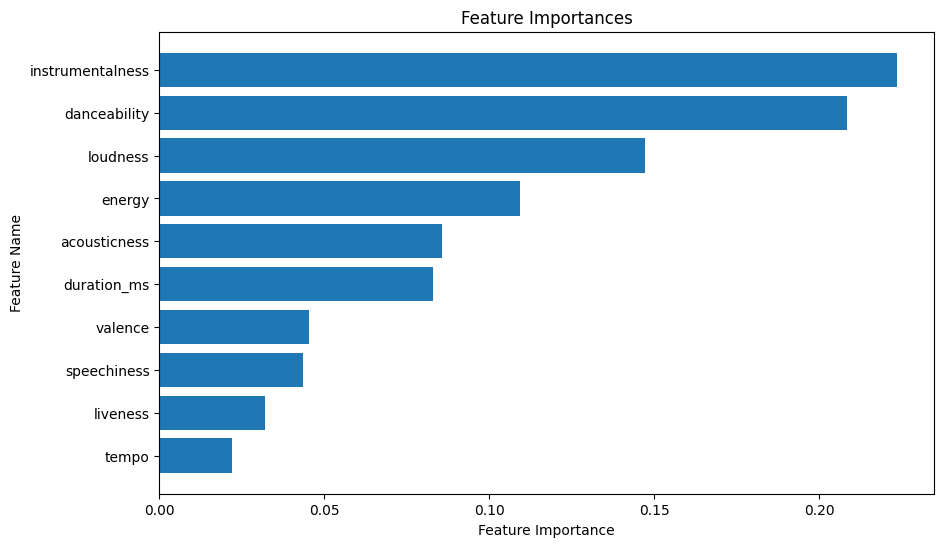

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, classification_report

# Fit the Gradient Boosting Classifier
gr_gb_clf.fit(X_train, y_train)

# Get feature importances
feature_importances = gr_gb_clf.best_estimator_.feature_importances_

# Create a DataFrame to associate feature names with importances
feature_names = X.columns
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort by importance (descending order)
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Print or visualize the feature importances
print(importances_df)

# Create a bar plot of feature importances
plt.figure(figsize=(10, 6))
plt.barh(importances_df['Feature'], importances_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert the y-axis to show the most important features at the top
plt.show()



mlflow.end_run()


## Retrain GB on top 5 features from above

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

current_run = mlflow.start_run()

X = songs[['danceability','energy','loudness','acousticness','instrumentalness', ]]
y = songs['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

param_grid = {'n_estimators': [50, 100, 200, 300, 400], 'learning_rate': [0.1, 0.01]}

gr_gb_clf = GridSearchCV(GradientBoostingClassifier(max_features=4, random_state=39),
                      param_grid=param_grid,
                      scoring='accuracy',
                      n_jobs=-1)

gr_gb_clf = gr_gb_clf.fit(X_train, y_train)

print('GradientBoost accuracy', accuracy_score(y_test, y_pred))
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


GradientBoost accuracy 0.8203190596137699
Area Under Curve: 0.7908036522622386
Recall score: 0.7486033519553073
Precision: 0.44224422442244227
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1012
           1       0.44      0.75      0.56       179

    accuracy                           0.82      1191
   macro avg       0.70      0.79      0.72      1191
weighted avg       0.87      0.82      0.84      1191

F1 score for minority class: 0.5560165975103735


## Retrain GB classifier without 'mode'

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

current_run = mlflow.start_run()

X = songs[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms']]
y = songs['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

param_grid = {'n_estimators': [50, 100, 200, 300, 400], 'learning_rate': [0.1, 0.01]}

gr_gb_clf = GridSearchCV(GradientBoostingClassifier(max_features=4, random_state=39),
                      param_grid=param_grid,
                      scoring='accuracy',
                      n_jobs=-1)

gr_gb_clf = gr_gb_clf.fit(X_train, y_train)

print('GradientBoost accuracy', accuracy_score(y_test, y_pred))
print(f'Area Under Curve: {roc_auc_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test,y_pred)}')
print(f'Precision: {precision_score(y_test,y_pred)}')
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


GradientBoost accuracy 0.8203190596137699
Area Under Curve: 0.7908036522622386
Recall score: 0.7486033519553073
Precision: 0.44224422442244227
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1012
           1       0.44      0.75      0.56       179

    accuracy                           0.82      1191
   macro avg       0.70      0.79      0.72      1191
weighted avg       0.87      0.82      0.84      1191

F1 score for minority class: 0.5560165975103735


# Stacking Classifier (LogRes, Random Forest, XGB. Meta: LogRes)

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict


current_run = mlflow.start_run()

X = songs[['danceability','energy','loudness', 'speechiness','acousticness','instrumentalness','liveness','valence', 'tempo', 'duration_ms',]]
y = songs['hit']
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Define base classifiers
base_classifiers = [
    ('logistic', LogisticRegression(class_weight={0: 954, 1: 5000})),
    ('random_forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=39)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=100))
]

# Define the meta-classifier
meta_classifier = LogisticRegression()

# Create the stacking classifier
stacking_classifier = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=meta_classifier,
)

# Define the cross-validation strategy, e.g., StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=39)

# Use cross_val_predict to perform cross-validation and get predictions
y_cv_pred = cross_val_predict(stacking_classifier, X_train, y_train, cv=cv)

# Fit the stacking classifier on the training data
stacking_classifier.fit(X_train, y_train)

# Make predictions using the stacking classifier
y_test_pred = stacking_classifier.predict(X_test)

# Evaluate the performance of the stacking classifier on the training data
print('Stacking Classifier (Cross-Validation) accuracy:', accuracy_score(y_train, y_cv_pred))
print('Confusion Matrix (Training Data):\n', confusion_matrix(y_train, y_cv_pred))
print('Classification Report (Training Data):\n', classification_report(y_train, y_cv_pred))

# Evaluate the performance of the stacking classifier on the test data
print('Stacking Classifier (Test Set) accuracy:', accuracy_score(y_test, y_test_pred))
print('Confusion Matrix (Test Set):\n', confusion_matrix(y_test, y_test_pred))
print('Classification Report (Test Set):\n', classification_report(y_test, y_test_pred))

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


Stacking Classifier (Cross-Validation) accuracy: 0.8616418223808524
Confusion Matrix (Training Data):
 [[3801  187]
 [ 472  303]]
Classification Report (Training Data):
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      3988
           1       0.62      0.39      0.48       775

    accuracy                           0.86      4763
   macro avg       0.75      0.67      0.70      4763
weighted avg       0.85      0.86      0.85      4763

Stacking Classifier (Test Set) accuracy: 0.8690176322418136
Confusion Matrix (Test Set):
 [[955  57]
 [ 99  80]]
Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.91      0.94      0.92      1012
           1       0.58      0.45      0.51       179

    accuracy                           0.87      1191
   macro avg       0.75      0.70      0.72      1191
weighted avg       0.86      0.87      0.86      1191

F1 score for minority class:

# Hard and Soft Voting Classifiers

In [ ]:
from sklearn.metrics import classification_report
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

current_run = mlflow.start_run()

# Define your base estimators
base_classifiers = [
    ('logistic', LogisticRegression(class_weight={0: 954, 1: 5000})),
    ('random_forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=39)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=100))
]


# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39)

# Create a hard voting ensemble
hard_voting_classifier = VotingClassifier(estimators=base_classifiers, voting='hard')
hard_voting_classifier.fit(X_train, y_train)
hard_voting_predictions = hard_voting_classifier.predict(X_test)

# Create a soft voting ensemble
soft_voting_classifier = VotingClassifier(estimators=base_classifiers, voting='soft')
soft_voting_classifier.fit(X_train, y_train)
soft_voting_predictions = soft_voting_classifier.predict(X_test)


# Generate a classification report for hard voting
hard_voting_classification_report = classification_report(y_test, hard_voting_predictions)
print('Classification Report for Hard Voting:\n', hard_voting_classification_report)

# Generate a classification report for soft voting
soft_voting_classification_report = classification_report(y_test, soft_voting_predictions)
print('Classification Report for Soft Voting:\n', soft_voting_classification_report)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


Classification Report for Hard Voting:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91      1012
           1       0.50      0.60      0.54       179

    accuracy                           0.85      1191
   macro avg       0.71      0.75      0.73      1191
weighted avg       0.86      0.85      0.85      1191

Classification Report for Soft Voting:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90      1012
           1       0.47      0.68      0.56       179

    accuracy                           0.84      1191
   macro avg       0.71      0.77      0.73      1191
weighted avg       0.87      0.84      0.85      1191

F1 score for minority class: 0.5560165975103735


In [ ]:
# Perform cross-validation for the soft voting ensemble
current_run = mlflow.start_run()

cv_scores = cross_val_score(soft_voting_classifier, X, y, cv=5)
cv_predictions = cross_val_predict(soft_voting_classifier, X, y, cv=5)

# Calculate and print the mean accuracy of cross-validation
print('Cross-Validation Mean Accuracy:', cv_scores.mean())

# Generate a classification report for cross-validation
cv_classification_report = classification_report(y, cv_predictions)
print('Classification Report for Cross-Validation:\n', cv_classification_report)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


Cross-Validation Mean Accuracy: 0.8348977273529059
Classification Report for Cross-Validation:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90      5000
           1       0.49      0.61      0.54       954

    accuracy                           0.83      5954
   macro avg       0.71      0.74      0.72      5954
weighted avg       0.85      0.83      0.84      5954

F1 score for minority class: 0.5560165975103735


In [ ]:
current_run = mlflow.start_run()

base_classifiers = [
    ('logistic', LogisticRegression(class_weight={0: 954, 1: 5000})),
    ('random_forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=39)),
    ('xgb', xgb.XGBClassifier(scale_pos_weight=100))
]
# Define the soft voting classifier
soft_voting_classifier = VotingClassifier(estimators=base_classifiers, voting='soft')

# Define the number of splits for stratified k-fold cross-validation
n_splits = 5  # You can adjust this as needed

# Initialize the StratifiedKFold cross-validator
stratified_kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation and get predictions
soft_voting_cv_predictions = cross_val_predict(soft_voting_classifier, X, y, cv=stratified_kfold)

# Calculate accuracy for the cross-validated predictions
soft_voting_cv_accuracy = accuracy_score(y, soft_voting_cv_predictions)
print('Soft Voting Cross-Validated Accuracy:', soft_voting_cv_accuracy)

# Generate a classification report for the cross-validated predictions
soft_voting_classification_report = classification_report(y, soft_voting_cv_predictions)
print('Classification Report for Soft Voting (Cross-Validated):\n', soft_voting_classification_report)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


Soft Voting Cross-Validated Accuracy: 0.8399395364460867
Classification Report for Soft Voting (Cross-Validated):
               precision    recall  f1-score   support

           0       0.92      0.88      0.90      5000
           1       0.50      0.61      0.55       954

    accuracy                           0.84      5954
   macro avg       0.71      0.75      0.73      5954
weighted avg       0.85      0.84      0.85      5954

F1 score for minority class: 0.5560165975103735


## Undersampling data before running Voting Classifier

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Create a random undersampler
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

# Apply random undersampling to your data
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

In [ ]:
current_run = mlflow.start_run()

# Define your base estimators
base_classifiers = [
    ('logistic', LogisticRegression()),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=39)),
    ('xgb', xgb.XGBClassifier())
]


# Create a soft voting ensemble
soft_voting_classifier = VotingClassifier(estimators=base_classifiers, voting='soft')
soft_voting_classifier.fit(X_resampled, y_resampled)
soft_voting_predictions = soft_voting_classifier.predict(X_test)

# Generate a classification report for soft voting
soft_voting_classification_report = classification_report(y_test, soft_voting_predictions)
print('Classification Report for Soft Voting:\n', soft_voting_classification_report)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


Classification Report for Soft Voting:
               precision    recall  f1-score   support

           0       0.97      0.77      0.86      1012
           1       0.40      0.87      0.54       179

    accuracy                           0.78      1191
   macro avg       0.68      0.82      0.70      1191
weighted avg       0.88      0.78      0.81      1191

F1 score for minority class: 0.5560165975103735


## SMOTE before running Voting Classifier

In [ ]:
from imblearn.over_sampling import SMOTE

# Create an instance of the SMOTE class
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
current_run = mlflow.start_run()

  # Define your base estimators
base_classifiers = [
      ('logistic', LogisticRegression()),
      ('random_forest', RandomForestClassifier(n_estimators=100, random_state=39)),
      ('xgb', xgb.XGBClassifier())
  ]


  # Create a soft voting ensemble
soft_voting_classifier = VotingClassifier(estimators=base_classifiers, voting='soft')
soft_voting_classifier.fit(X_train_smote, y_train_smote)
soft_voting_predictions = soft_voting_classifier.predict(X_test)

  # Generate a classification report for soft voting
soft_voting_classification_report = classification_report(y_test, soft_voting_predictions)
print('Classification Report for Soft Voting:\n', soft_voting_classification_report)

  # Calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate recall score for the minority class (assuming minority class label is 1)
f1_1 = f1_score(y_test, y_pred, labels=[1])
print(f'ROC_AUC: {roc_auc}')

# Print the recall score for the minority class
print(f'F1 score for minority class: {f1_1}')
# Log test metrics manually
mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_roc_auc": roc_auc,
        "test_recall": recall,
        "test_precision": precision,
        "test_f1": f1,
        "test_f1_1": f1_1
})

mlflow.end_run()


Classification Report for Soft Voting:
               precision    recall  f1-score   support

           0       0.94      0.86      0.90      1012
           1       0.48      0.71      0.57       179

    accuracy                           0.84      1191
   macro avg       0.71      0.79      0.74      1191
weighted avg       0.87      0.84      0.85      1191

ROC_AUC: 0.7908036522622386
F1 score for minority class: 0.5560165975103735


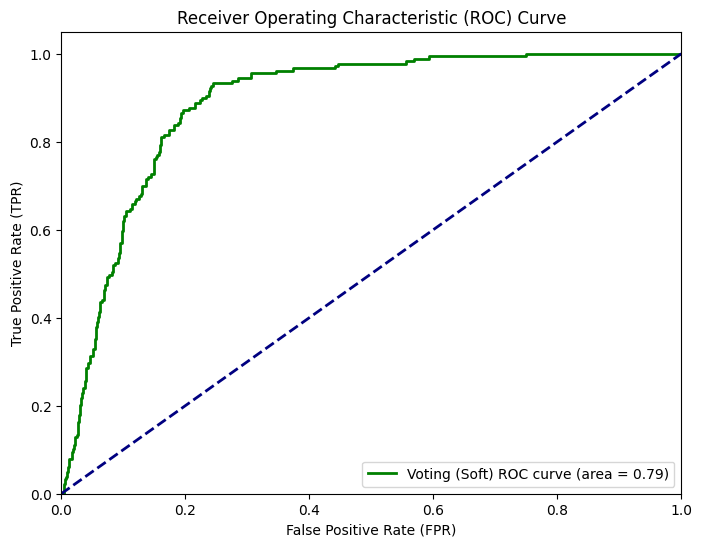

ROC_AUC: 0.7908036522622386


In [ ]:
y_pred_proba = soft_voting_classifier.predict_proba(X_test)[:, 1]

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr_soft, tpr_soft, _ = roc_curve(y_test, y_pred_proba)
roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_soft, tpr_soft, color='green', lw=2, label='Voting (Soft) ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print(f'ROC_AUC: {roc_auc}')
